# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 02: Extracción y Transformación de Datos </center></h1>

**Fecha de Entrega:** 25 de septiembre de 2025, a las 23:59.

**Fecha de publicación**: 2 de septiembre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 02 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, queremos comprender y visualizar la distribución de aves migratorias en el territorio chileno. Específicamente, queremos entender las diferencias entre las migraciones de 2 especies en particular, el run-run y la dormilona tontita, a partir de los avistamientos registrados en eBird durante un periodo de 3 años y medio.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

### 1.4 Ejemplo de visualización

Esta tarea se enfoca en datos de aves. Para complementarla, les compartimos la siguiente página web, llamada "Bird Migration Explorer" que les permite visualizar, de una forma novedosa e interesante, las rutas de migración de aves en las Americas. Visiten la página para que vean cómo se puede visualizar datos de una manera interesante y novedosa, que podría ustedes usar en el futuro para sus proyectos.

In [2]:
from IPython.display import IFrame
IFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)

## 2. Datos

Los datos a utilizar provienen de la plataforma **[eBird](https://ebird.org/)**, una aplicación desarrollada por The Cornell Lab of Ornithology que permite a sus usuarios registrar y compartir avistamientos de aves en todo el mundo. La plataforma dispone de una API mediante la cual se pueden realizar consultas sobre avistamientos de aves recientes e históricos, especies según región, taxonomía, entre otros. 

### 2.1 Acceso a la API

Muchas API pueden utilizarse solo mediante el uso de una clave única, o "API key". Para conseguir una API key en eBird, primero debe ser usuario de la plataforma. Puede crear una cuenta aquí: https://secure.birds.cornell.edu/identity/account/create


Con una cuenta ya creada, puede ingresar a https://ebird.org/api/keygen para generar su llave. Debe llenar un formulario de solicitud al pedir su llave. Como sugerencia, puede llenar los campos con la siguiente información:

* **Organización:** Pontificia Universidad Católica de Chile
* **Título del Proyecto:** Tarea IMT2200 Introducción a Ciencia de Datos
* **Descripción:** "Uso educativo para exploración y análisis de distribución de aves migratorias en Chile."
* **Tipo de Proyecto:** Academic/Student
* **Casos de uso:** Materiales educativos y artíticos (...)

Debería recibir su llave inmediatamente después de enviar su solicitud. Como recomendación, puede revisar la documentación de la API en el siguiente link: https://documenter.getpostman.com/view/664302/S1ENwy59#intro

#### 2.2 Mapoteca de BCN

Para esta tarea queremos visualizar el movimiento de aves a lo largo de nuestro país. Para ello, también necesitaremos manejar datos geoespaciales: específicamente, trabajaremos con un mapa vectorial de Chile disponible en la página web de la Biblioteca del Congreso Nacional: https://www.bcn.cl/siit/mapas_vectoriales/index_html

Descargue el archivo `.zip` para las **Divisiones regionales** y descomprímalo. Dentro de esta carpeta, habrá un archivo llamado `Regional.shp`, que utilizaremos con `geopandas` para graficar nuestro mapa de Chile.

### 2.3 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [3]:
import requests
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
# La voy a ocupar para ver si existe el archivo 
from pathlib import Path
# Se ocupa en 3.2
from shapely.geometry import Point

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 Extracción de datos (1.5 puntos)

**(1 pto)** Vamos a crear nuestra base de datos con los avistamientos registrados en eBird dentro de Chile desde 2022 hasta 2025. Revise la documentación de la API y averigue cómo extraer los avistamientos de un día. Luego extraiga los avistamientos para todos los días desde el **1 de enero de 2022 hasta el 31 de julio de 2025.** Cuando haya logrado extraer todos los datos, guárdelos en un archivo CSV o parquet.

Responda:

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

**Recomendaciones:** 
* Puede usar la librería `datetime` para generar fechas: cree una lista con todas las fechas e itere sobre esta lista para hacer los llamados a la API.
* **Pruebe primero con uno o dos días** para verificar el funcionamiento de su código y de la API.
* Inspeccione la forma en la que vienen los datos.
* Vaya guardando los datos extraídos en archivos (CSV o parquet), de modo que no tenga que repetir los llamados en caso de algún error.

**Hint**: Los códigos regionales chilenos para la API son los siguientes,
* `regionCode = CL`
* `sppLocale = es_CL` (para obtener nombres chilenos de las aves)

In [4]:
# Desarrollo a

# Se lee el archivo.txt que tiene mi key
archivo = open("Api.txt", "r")
dato = archivo.readlines()
archivo.close
key = dato[0].strip().split("=")
key = key[1]

# Se hace la lista de las fechas
inicio_fecha = datetime.datetime(2022, 1, 1)
termino_fecha = datetime.datetime(2025, 7, 31)
lista_fechas = []
for i in range((termino_fecha - inicio_fecha).days + 1):
    lista_fechas.append(inicio_fecha + datetime.timedelta(days=i))


In [5]:
# Desarrollo a

# Se llaman cada registro
headers = {"X-eBirdApiToken": key}
lista_datos = []
anio_actual = None
# Se hace para concadenar los df si existe un archivo.csv
ultimo_anio_csv = None
for i, fecha in enumerate(lista_fechas):
    fecha_str = str(fecha)[:10]
    anio = fecha_str[:4]
    mes = fecha_str[5:7]
    dia = fecha_str[8:]
    if anio_actual is None:
        anio_actual = anio
    # Cuando cambia de año guarda los datos hasta el año anterior
    if anio_actual != anio:
        nombre_archivo = f"avistamientos_{anio_actual}.csv"
        if len(lista_datos) > 0:
            df_temp = pd.DataFrame(lista_datos)
            df_temp.to_csv(nombre_archivo, index=False)
            print(f"Se guardaron los avistamientos hasta el año {anio_actual} en {nombre_archivo}")
        anio_actual = anio
    # Si existe el archivo, entonces salta esa fecha
    if Path(f"avistamientos_{anio_actual}.csv").exists():
        ultimo_anio_csv = anio_actual
        continue
    else:
        url = f"https://api.ebird.org/v2/data/obs/CL/historic/{anio}/{mes}/{dia}?sppLocale=es_CL"
        r = requests.get(url, headers=headers)
        if r.status_code == 200:
            info = r.json()
            lista_datos.extend(info)
        else:
            print(f"Eror en {fecha_str}")
    if i == len(lista_fechas) - 1:
        nombre_archivo = f"avistamientos_{anio_actual}.csv"
        if len(lista_datos) > 0:
            df_temp = pd.DataFrame(lista_datos)
            df_temp.to_csv(nombre_archivo, index=False)
            print(f"Se guardaron los avistamientos hasta el año {anio_actual} en {nombre_archivo}")


In [6]:
# Desarrollo a

if ultimo_anio_csv is None:
    df = pd.DataFrame(lista_datos)
else:
    # Si existia el archivo, entonces se unen los 2 df
    df = pd.read_csv(f"avistamientos_{ultimo_anio_csv}.csv")
    df_temp = pd.DataFrame(lista_datos)
    df = pd.concat([df, df_temp], ignore_index=True)
# Guardamos los datos en un .csv
df.to_csv("avistamientos_2022-2025.csv", index=False)

print(f"Mi dataset tiene un total de {len(df)} avistamientos")


Mi dataset tiene un total de 272195 avistamientos


**Respuesta a**:

El total de avistamientos que hay en mi dataset desde el 1 de enero del 2022 hasta el 31 de julio de 2025 es de 272.195.

In [7]:
# Respuesta b
conteo = df['comName'].value_counts()
print(f"Numero de dias: {len(lista_fechas)}")
print(conteo)



Numero de dias: 1308
comName
Paloma doméstica          1308
Diucón                    1308
Yeco                      1308
Paloma de alas blancas    1308
Diuca común               1308
                          ... 
Bolsero de Baltimore         1
Petrel de cara gris          1
Playero zarapito             1
Yunco geórgico               1
Petrel antártico             1
Name: count, Length: 533, dtype: int64


**Respuesta b**:

Se observa que varias especies se repiten un total de 1308 veces. Esto se debe a que la cantidad de dias que se registran en el dataset es justamente 1308, lo que indica que cada especie que tiene un total de 1308 avistamientos fue vista al menos una vez por dia. Tambien, sugiere que esas especies son avistadas diariamente y que la cantidad maxima de avistamientos esta limitada por la cantidad de dias que tiene registrados el dataset.


### 3.2 Tranformación (1 punto)

**a) (0.5 pts)** Transforme la columna `obsDt` de string a un objeto de tipo `datetime` únicamente con año, mes y día (YYYY-MM-DD). Luego, agregue las siguientes nuevas columnas:
* `month` con únicamente el mes del avistamiento (puede dejar el mes como número entero de 1 a 12).
* `year-month` con el mes y año fecha en formato YYYY-MM

In [8]:
# Respuesta

'''
Me apoye de:
https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html#pandas.to_datetime
https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.to_period.html
https://pandas.pydata.org/docs/user_guide/timeseries.html#timeseries-period-aliases
https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.date.html
https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.month.html
'''


df['obsDt'] = pd.to_datetime(df['obsDt'], format='mixed').dt.date
df['month'] = pd.to_datetime(df['obsDt'], format='mixed').dt.month
df['year-month'] = pd.to_datetime(df['obsDt'], format='mixed').dt.to_period('M')
df.head()

,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01,3.0,-40.585844,-73.113157,True,False,True,S99916680,NaN,1,2022-01
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01,4.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01
3,austhr1,Zorzal patagónico,Turdus falcklandii,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01
4,rucspa1,Chincol,Zonotrichia capensis,L7988120,"Leñadura, Nuestra casa",2022-01-01,2.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01


**b) (0.5 pts)** Averigue cómo tranformar su DataFrame de Pandas en un GeoDataFrame de GeoPandas. Para esto, utilice las columnas `lat`y `lng` para generar los puntos de la nueva columna `geometry`. Para las visualizaciones siguientes utilizaremos el Coordinate Reference System (CRS) EPSG 4326 (también llamado [WGS 84](https://es.wikipedia.org/wiki/WGS84)). Asegúrese que sus coordenadas correspondan a este CRS al crear su GeoDataFrame.

In [9]:
# Respuesta

'''
Me guie con este video:

https://www.youtube.com/watch?v=_ZllarZgc-k
'''

geometry = [Point(xy) for xy in zip(df['lng'], df['lat'])]

gdf = gpd.GeoDataFrame(df, crs="EPSG:4326", geometry=geometry)

print(gdf)

       speciesCode                   comName                   sciName  \
0          soulap1           Queltehue común        Vanellus chilensis   
1          bkfibi1           Bandurria común     Theristicus melanopis   
2          grhowl2                 Tucúquere         Bubo magellanicus   
3          austhr1         Zorzal patagónico        Turdus falcklandii   
4          rucspa1                   Chincol      Zonotrichia capensis   
...            ...                       ...                       ...   
272190     wbctyr1               Pitajo gris      Ochthoeca leucophrys   
272191     baytan3                 Naranjero       Rauenia bonariensis   
272192     bktflo1            Comesebo negro   Diglossa brunneiventris   
272193     rngtyr1  Dormilona de nuca rojiza  Muscisaxicola rufivertex   
272194     orntin1       Perdiz cordillerana        Nothoprocta ornata   

            locId                                            locName  \
0       L10140471  Villa Parque Austral

### 3.3 Exploración del dataset (1 punto)

**a) (0.3 pts)** Utilice `geopandas` para leer el archivo `Regional.shp` descargado de BCN. Asegúrese de que su CRS sea el mismo que utilizó en la sección anterior.

In [10]:
# Respuesta
ruta = Path('Regiones', 'Regional.shp')

regional_gdf = gpd.read_file(ruta)
regional_gdf = regional_gdf.to_crs(epsg=4326)

regional_gdf.head()

,objectid,cir_sena,codregion,area_km,st_area_sh,st_length_,Region,geometry
0,1084,1,15,16866.819844,1.886869e+10,7.505296e+05,Región de Arica y Parinacota,"POLYGON ((-69.41531 -17.65521, -69.40802 -17.6..."
1,1085,2,1,42284.567484,4.830637e+10,1.213713e+06,Región de Tarapacá,"MULTIPOLYGON (((-70.16034 -20.2107, -70.16031 ..."
2,1086,3,2,126071.431981,1.508452e+11,2.516112e+06,Región de Antofagasta,"MULTIPOLYGON (((-70.70164 -25.89174, -70.7013 ..."
3,1087,15,12,133053.142345,3.581316e+11,9.049830e+07,Región de Magallanes y Antártica Chilena,"MULTIPOLYGON (((-67.32026 -55.92015, -67.31971..."
4,1088,14,11,106703.377369,2.242743e+11,4.144481e+07,Región de Aysén del Gral.Ibañez del Campo,"MULTIPOLYGON (((-75.57992 -48.75893, -75.58028..."


**b) (0.7 pts)** Grafique un mapa de Chile con todos los avistamientos de su dataset como puntos en el mapa. Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 

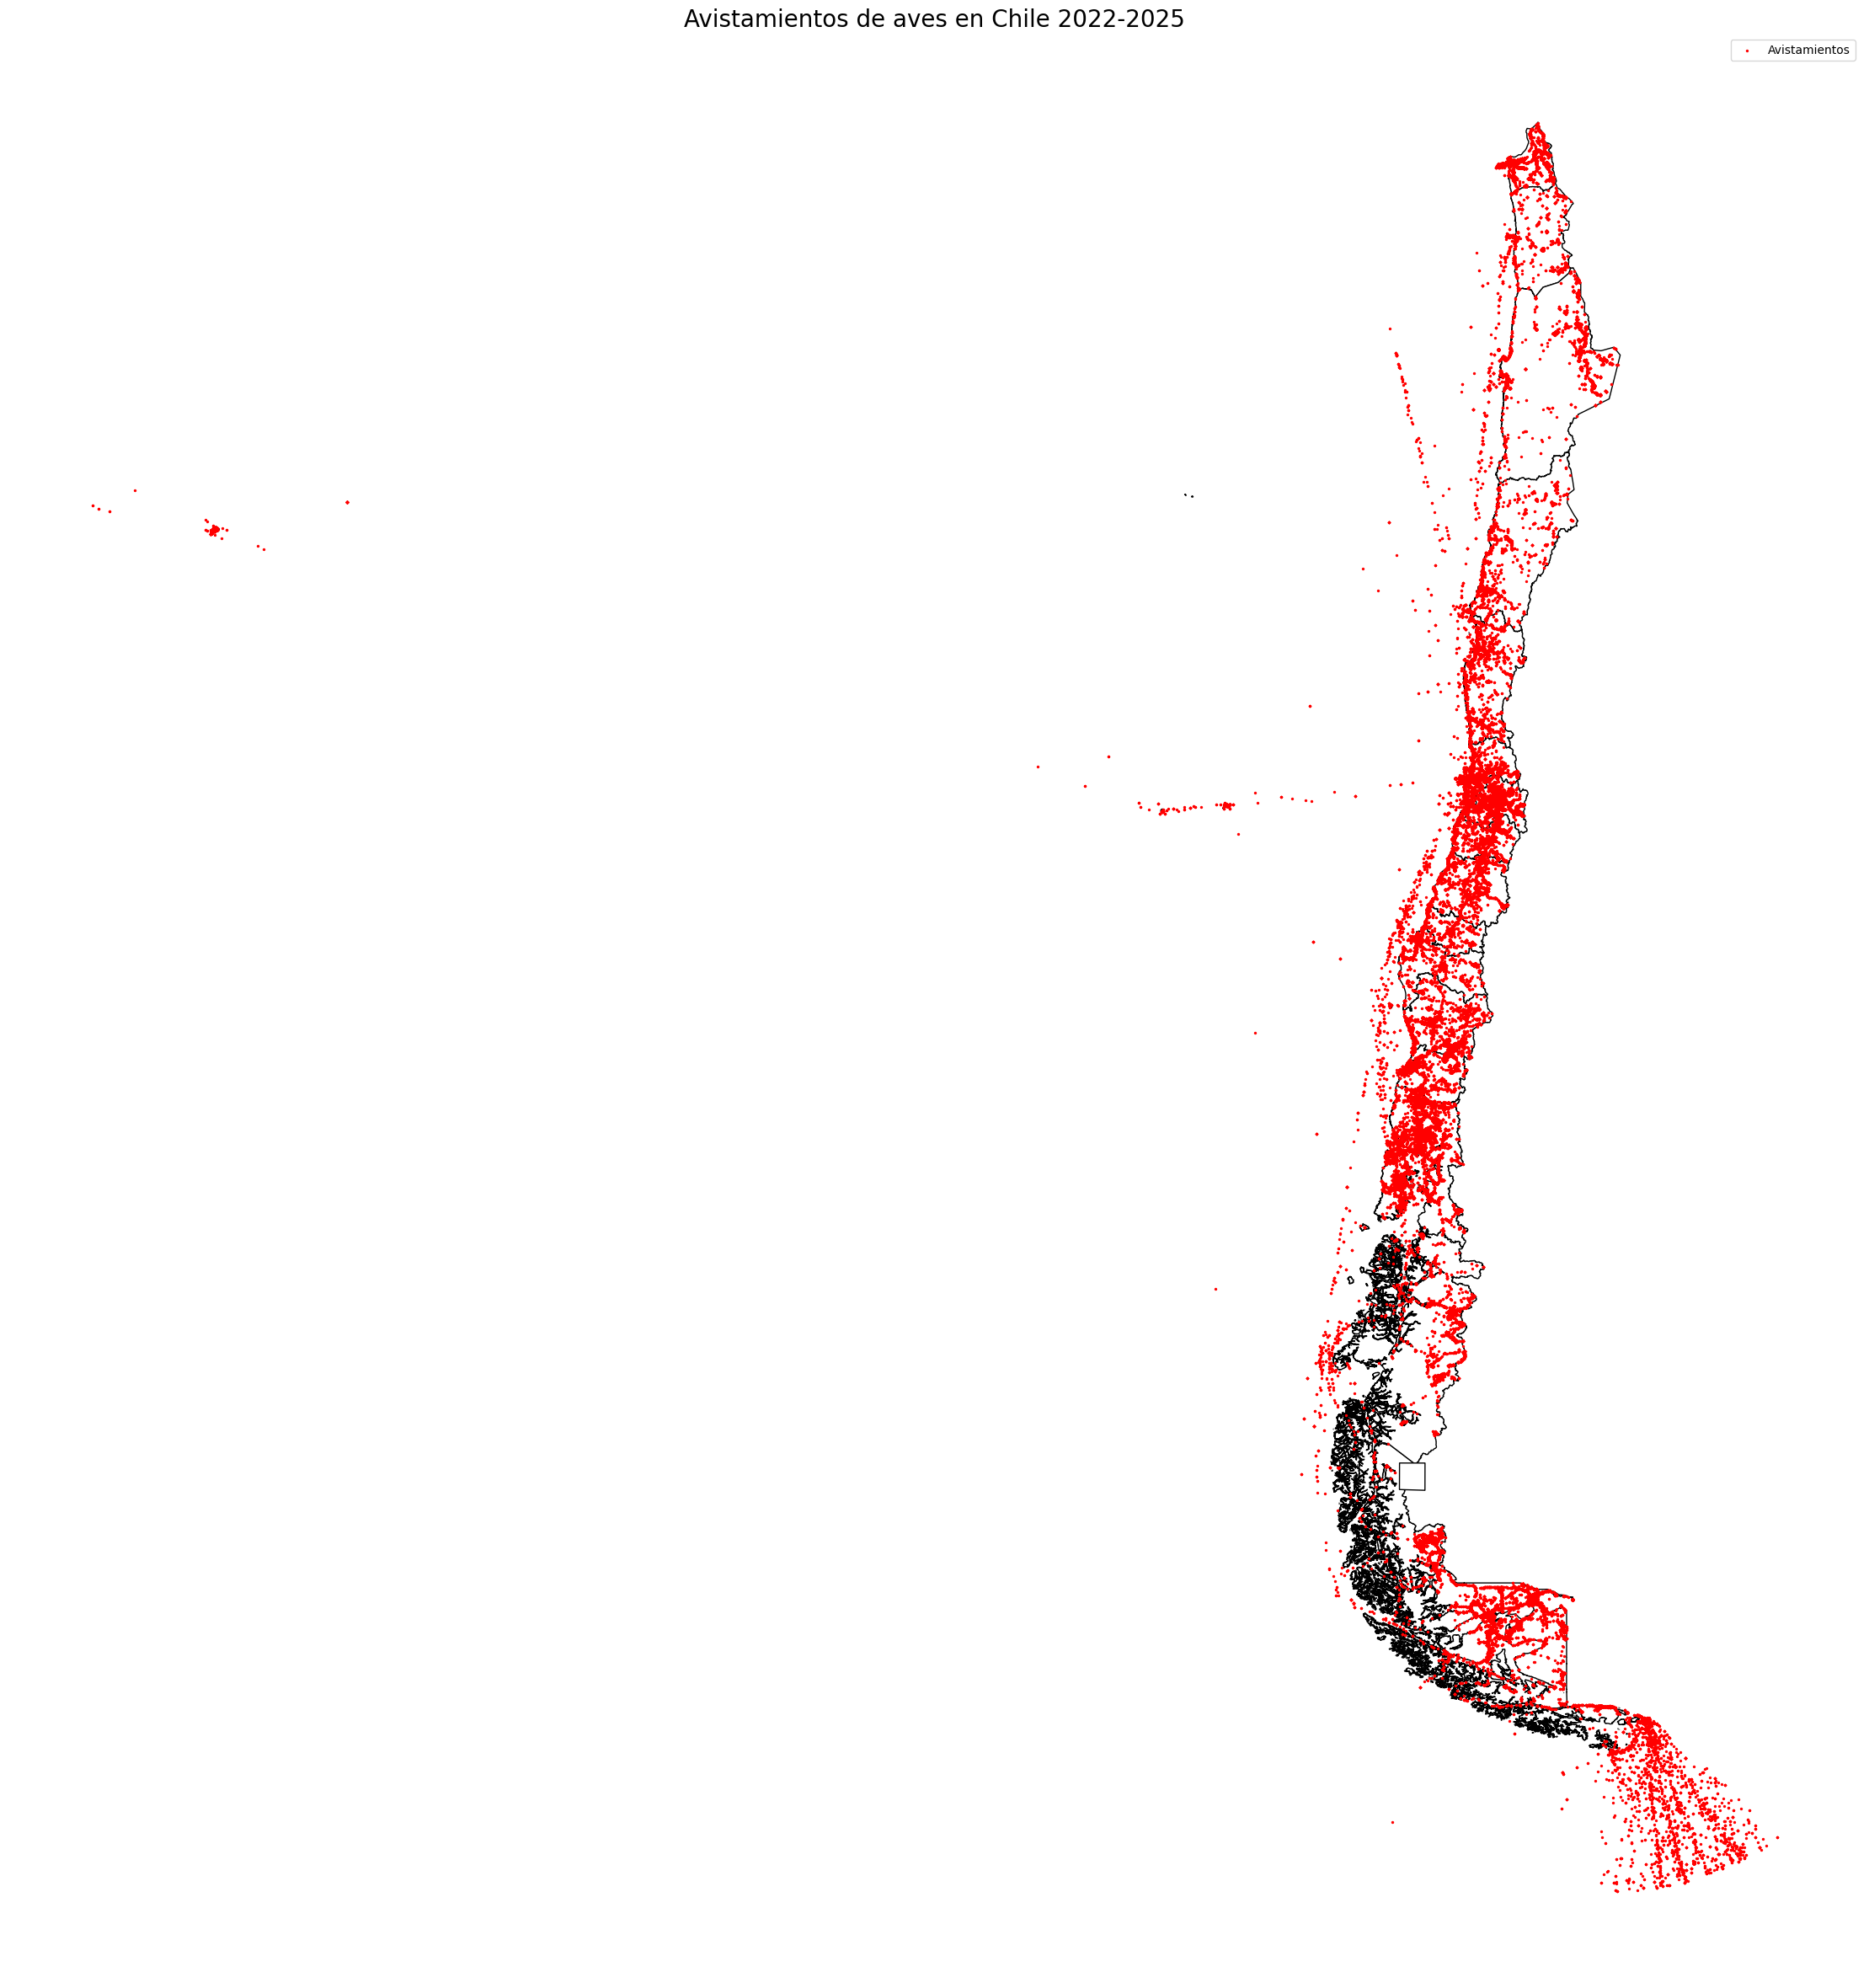

In [11]:
# Respuesta

fig, ax = plt.subplots(figsize=(30, 30))
regional_gdf.plot(ax=ax, color='white', edgecolor='black')
gdf.plot(ax=ax, color='red', markersize=2, label='Avistamientos')
ax.set_title('Avistamientos de aves en Chile 2022-2025', fontsize=20)
ax.legend()
ax.set_axis_off()

plt.show()

Estos avistamientos se distribuyen a lo largo de todo Chile, y estos avistamientos se concentran mayormente en la parte central (Valparaiso y la Region Metropolitana) y sur de Chile (Puerto Montt, Temuco y Concepcion), mientras que en el norte y partes del extremos sur, como Antofagasta y Coyhaique, hay menor concentracion de avistamientos.

### 3.4 Visualización de migraciones (2.5 puntos)

**a) (0.2 pts)** Vamos a inspeccionar los avistamientos de las siguientes 2 especies en particular:

* Run-run [(*Hymenops perspicillatus*)](https://www.avesdechile.cl/171.htm)
* Dormilona tontita [(*Muscisaxicola maclovianus*)](https://www.avesdechile.cl/043.htm)

Primero, genere dos nuevos dataframes con los avistamientos de cada especie por separado.

In [12]:
# Respuesta

df_runrun = df[df['comName'] == "Run-run"]
df_runrun.head()

,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month
49,spetyr1,Run-run,Hymenops perspicillatus,L17285264,"1711270, La Serena CL-Regione di Coquimbo -29....",2022-01-01,1.0,-29.899139,-71.270972,True,False,True,S99876937,NaN,1,2022-01
204,spetyr1,Run-run,Hymenops perspicillatus,L17285264,"1711270, La Serena CL-Regione di Coquimbo -29....",2022-01-02,2.0,-29.899139,-71.270972,True,False,True,S99980322,NaN,1,2022-01
517,spetyr1,Run-run,Hymenops perspicillatus,L6511037,SN Humedal Angachilla--Puente Angachilla,2022-01-03,11.0,-39.866534,-73.238726,True,False,False,S100101766,NaN,1,2022-01
579,spetyr1,Run-run,Hymenops perspicillatus,L9860617,Llanquihue--Humedal Baquedano,2022-01-04,1.0,-41.250278,-73.008892,True,False,False,S100131688,NaN,1,2022-01
805,spetyr1,Run-run,Hymenops perspicillatus,L17401377,Isla Teja--Humedal Sur,2022-01-05,1.0,-39.820261,-73.258060,True,False,False,S100197285,NaN,1,2022-01


In [13]:
df_dormilona = df[df['comName'] == "Dormilona tontita"]
df_dormilona.head()

,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month
389,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L17444141,Base de Las Torres,2022-01-02,5.0,-50.914148,-72.966255,True,False,True,S100809770,NaN,1,2022-01
513,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L13297147,Río Alerce--Cascada Llanada Grande,2022-01-03,4.0,-41.871237,-71.920478,True,False,False,S100063840,NaN,1,2022-01
749,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L1259323,PN Torres del Paine--Trek a mirador Torres del...,2022-01-04,2.0,-50.952222,-72.924585,True,False,False,S100992257,NaN,1,2022-01
939,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L1030753,PN Torres del Paine--Lago Grey (sector sur),2022-01-05,2.0,-51.116510,-73.122983,True,False,False,S101584897,NaN,1,2022-01
1539,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L17443772,"Sendero Volcán Casablanca, Los Lagos, CL (-40....",2022-01-08,1.0,-40.771117,-72.171518,True,False,True,S100805036,NaN,1,2022-01


**b) (0.8 pts)** Para cada una de estas especies, agrupe los datos según `year-month`. Luego, realice un gráfico que muestre la cantidad de avistamientos en el tiempo, empezando desde enero del 2022 hasta julio de 2025. Responda: ¿cómo varía cantidad de avistamientos para estas dos especies? ¿Cuáles son sus diferencias?

In [14]:
# Respuesta

runrun_conteo = df_runrun.groupby('year-month').size().rename("Run-run")
print(runrun_conteo)

year-month
2022-01    31
2022-02    28
2022-03    28
2022-04     9
2022-05     1
2022-08     1
2022-09    19
2022-10    31
2022-11    30
2022-12    31
2023-01    31
2023-02    28
2023-03    27
2023-04     8
2023-05     3
2023-07     3
2023-08     2
2023-09    16
2023-10    31
2023-11    30
2023-12    31
2024-01    31
2024-02    29
2024-03    27
2024-04     8
2024-05     3
2024-07     1
2024-08     1
2024-09    15
2024-10    30
2024-11    30
2024-12    31
2025-01    31
2025-02    28
2025-03    29
2025-04     9
2025-07     1
Freq: M, Name: Run-run, dtype: int64


In [15]:
# Respuesta
dormilona_conteo = df_dormilona.groupby('year-month').size().rename("Dormilona tontita")
print(dormilona_conteo)

year-month
2022-01    16
2022-02    19
2022-03    18
2022-04    27
2022-05    31
2022-06    30
2022-07    31
2022-08    29
2022-09    30
2022-10    29
2022-11    19
2022-12    20
2023-01    22
2023-02    16
2023-03    26
2023-04    23
2023-05    31
2023-06    29
2023-07    31
2023-08    31
2023-09    30
2023-10    31
2023-11    27
2023-12    21
2024-01    25
2024-02    25
2024-03    27
2024-04    24
2024-05    31
2024-06    30
2024-07    31
2024-08    31
2024-09    30
2024-10    29
2024-11    29
2024-12    23
2025-01    27
2025-02    28
2025-03    30
2025-04    26
2025-05    31
2025-06    30
2025-07    31
Freq: M, Name: Dormilona tontita, dtype: int64


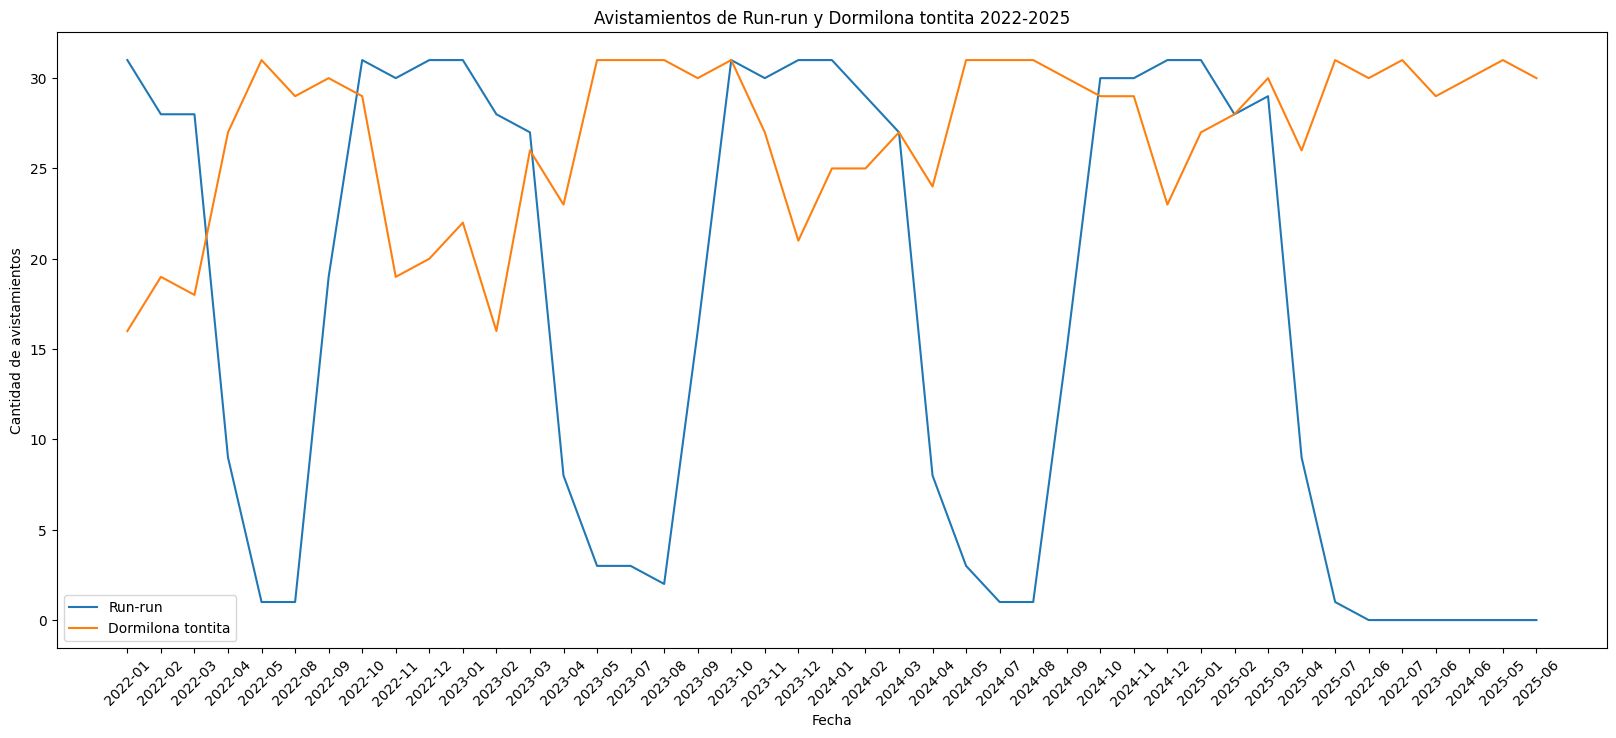

In [16]:
df_conteo = pd.concat([runrun_conteo, dormilona_conteo], axis=1)
df_conteo = df_conteo.fillna(0)
df_conteo = df_conteo.astype(int)
df_conteo.index = df_conteo.index.astype(str)

plt.figure(figsize=(20,8))
plt.plot(df_conteo.index, df_conteo['Run-run'], label='Run-run')
plt.plot(df_conteo.index, df_conteo['Dormilona tontita'], label='Dormilona tontita')

plt.title('Avistamientos de Run-run y Dormilona tontita 2022-2025')
plt.xlabel('Fecha')
plt.ylabel("Cantidad de avistamientos")
plt.xticks(rotation=45)
plt.legend()

plt.show()

La cantidad de avistamientos varia significativamente entre el Run-run y la Dormilona tontita. La especie Run-run presenta cambios en su comportamientos muy marcados en ciertas estaciones del año, por ejemplo, entre mayo y agosto de cada año los avistamientos del Run-run caen casi a 0, mientras que en otros periodos del año como primavera y verano los avistamientos del Run-run son practicamente diarios. Esto puede indicar que esta especie migra o reduce su actividad entre mayo y agosto, haciendo que no se aviste esta especie durante esas fechas.

Por otro lado, la especie Dormilona tontita mantiene una presencia mucho mas constante a lo largo de los años, haciendo que sus avistamientos no caigan abruptamente a casi 0 (a diferencia del Run-run), sus avistamientos cada mes suelen estar entre 20-30 dias cada mes. Esto puede indicar que esta especie se muestra constantemente durante el año, aunque igual hay momentos donde reduce su avistamiento, pero no baja de 15 avistamientos por mes.

**b) (1 pto)** Grafique en un mapa de Chile la ubicación de cada avistamiento para cada especie mencionada por separado. Utilice el color de cada punto como indicador del mes de avistamiento (columna `month`). Para esto, utilice un **colormap cíclico** para representar los meses del año. Puede utilizar el colormap disponible en la siguiente celda, o bien utilizar otro (siempre y cuando sea cíclico).

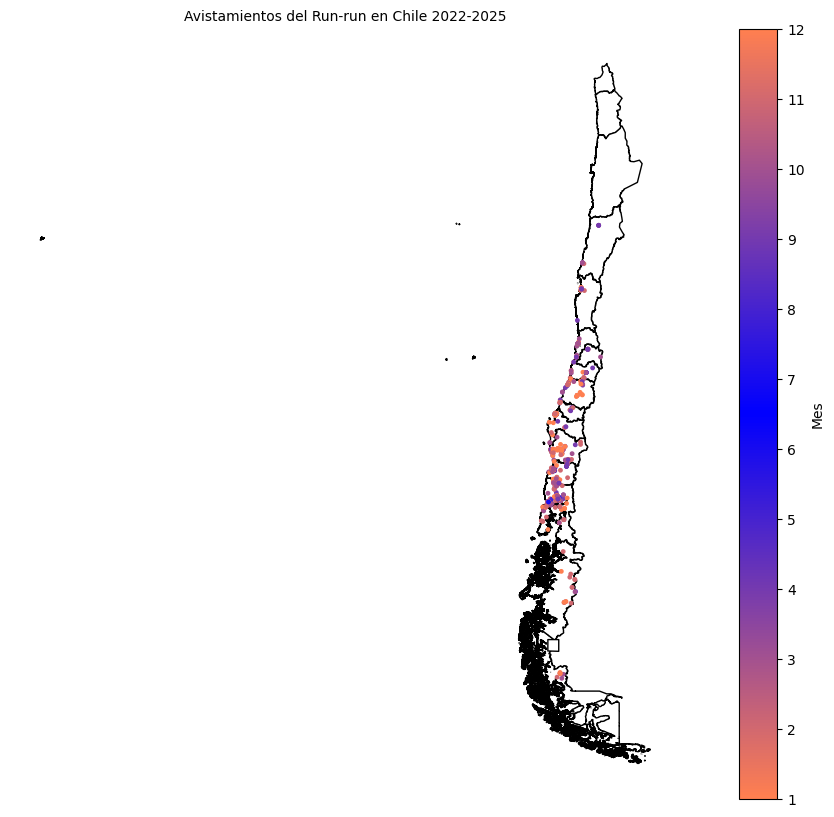

In [22]:
import matplotlib.colors as mcolors
colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]

# Creamos un colormap cíclico para representar meses del año
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))

'''
Me apoye de:
https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html
'''

geometry_runrun = [Point(xy) for xy in zip(df_runrun['lng'], df_runrun['lat'])]

gdf_runrun = gpd.GeoDataFrame(df_runrun, crs="EPSG:4326", geometry=geometry_runrun)

fig, ax = plt.subplots(figsize=(15, 10))
regional_gdf.plot(ax=ax, color='white', edgecolor='black')
gdf_runrun.plot(ax=ax, column='month', cmap=custom_cmap, legend=True, legend_kwds={'label': 'Mes', 'ticks':range(1, 13)}, markersize=6)
ax.set_title('Avistamientos del Run-run en Chile 2022-2025', fontsize=10)
ax.set_axis_off()

plt.show()


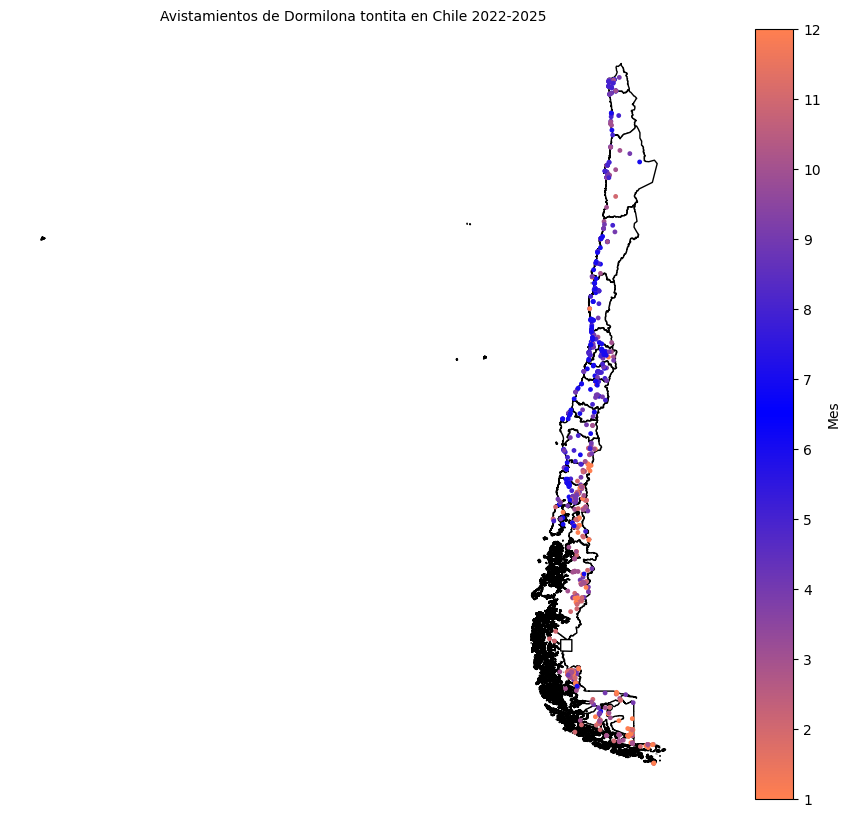

In [ ]:
# Respuesta

geometry_dormilona = [Point(xy) for xy in zip(df_dormilona['lng'], df_dormilona['lat'])]

gdf_dormilona = gpd.GeoDataFrame(df_dormilona, crs="EPSG:4326", geometry=geometry_dormilona)

fig, ax = plt.subplots(figsize=(15, 10))
regional_gdf.plot(ax=ax, color='white', edgecolor='black')
gdf_dormilona.plot(ax=ax, column='month', cmap=custom_cmap, legend=True, legend_kwds={'label': 'Mes', 'ticks':range(1, 13)},markersize=6)
ax.set_title('Avistamientos de Dormilona tontita en Chile 2022-2025', fontsize=10)
ax.set_axis_off()

plt.show()

**c) (0.5 pts)** Describa las migraciones de estas dos especies. ¿Cómo se diferencian?

* Respuesta:

Las principales diferencias entre las migraciones de la especie Run-run y la especie Dormilona tontita son que los avistamientos de la Dormilona tontita se distribuyen a lo largo de casi todo Chile, se puede ver que esta presente en todos los meses, ademas que esta en verano se avista en zonas extremas del sur mientras que en otras estaciones se logra avistar por casi todo el largo de Chile.

Por otro lado, los avistamientos del Run-run se concentran principalmente en la zona central y del sur de Chile, no en todo el pais a diferencia de la dormilona tontita que se avista por casi todo Chile. Ademas, se puede observar que esta tiene avistamientos principalmente en las estaciones de verano y primavera, y esta no se logra avistar practicamente nunca en la estacion de invierno, lo que sugiere que el Run-run no esta presente en Chile durante todo el año y posiblemente salga de Chile durante las epocas en las que no se avista.

En resumen, las principales diferencias entre el Run-run y la dormilona tontita es que el Run-run no se avista todo el año mientras que la dormilona tontita si se avista todo el año, tambien que el Run-run se desplaza solo en zonas especificas mientras que la dormilona se mueve por todo Chile.
